## Vendor Performance Analysis and Visualization

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
from scipy.stats import ttest_ind
from sqlalchemy import create_engine
from engine import engine

In [63]:
df=pd.read_sql_query("Select * from vendor_sales_summary", con=engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


##### Exploratory Data Analysis
Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [64]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,10640.705203,18700.404409,2.000000,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,18054.503193,12643.196784,58.000000,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,24.402095,109.483355,0.360000,6.840000,10.450000,19.470000,5.681810e+03
Volume,10648.0,847.883875,665.354152,50.000000,750.000000,750.000000,750.000000,2.000000e+04
ActualPrice,10648.0,35.671184,148.534066,0.490000,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10648.0,3145.159936,11113.367455,1.000000,36.000000,261.000000,1981.250000,3.376600e+05
TotalPurchaseDollars,10648.0,30138.163064,123277.154715,0.710000,452.857500,3646.725000,20764.170000,3.811252e+06
TotalSalesQuantity,10648.0,3081.902047,10971.073340,0.000000,33.000000,260.500000,1934.250000,3.349390e+05
TotalSalesDollars,10648.0,42302.921643,167947.264974,0.000000,728.275000,5285.915000,28414.050000,5.101920e+06
TotalSalesPrice,10648.0,18813.647626,45018.406384,0.000000,288.830000,2841.775000,16080.270000,6.728193e+05


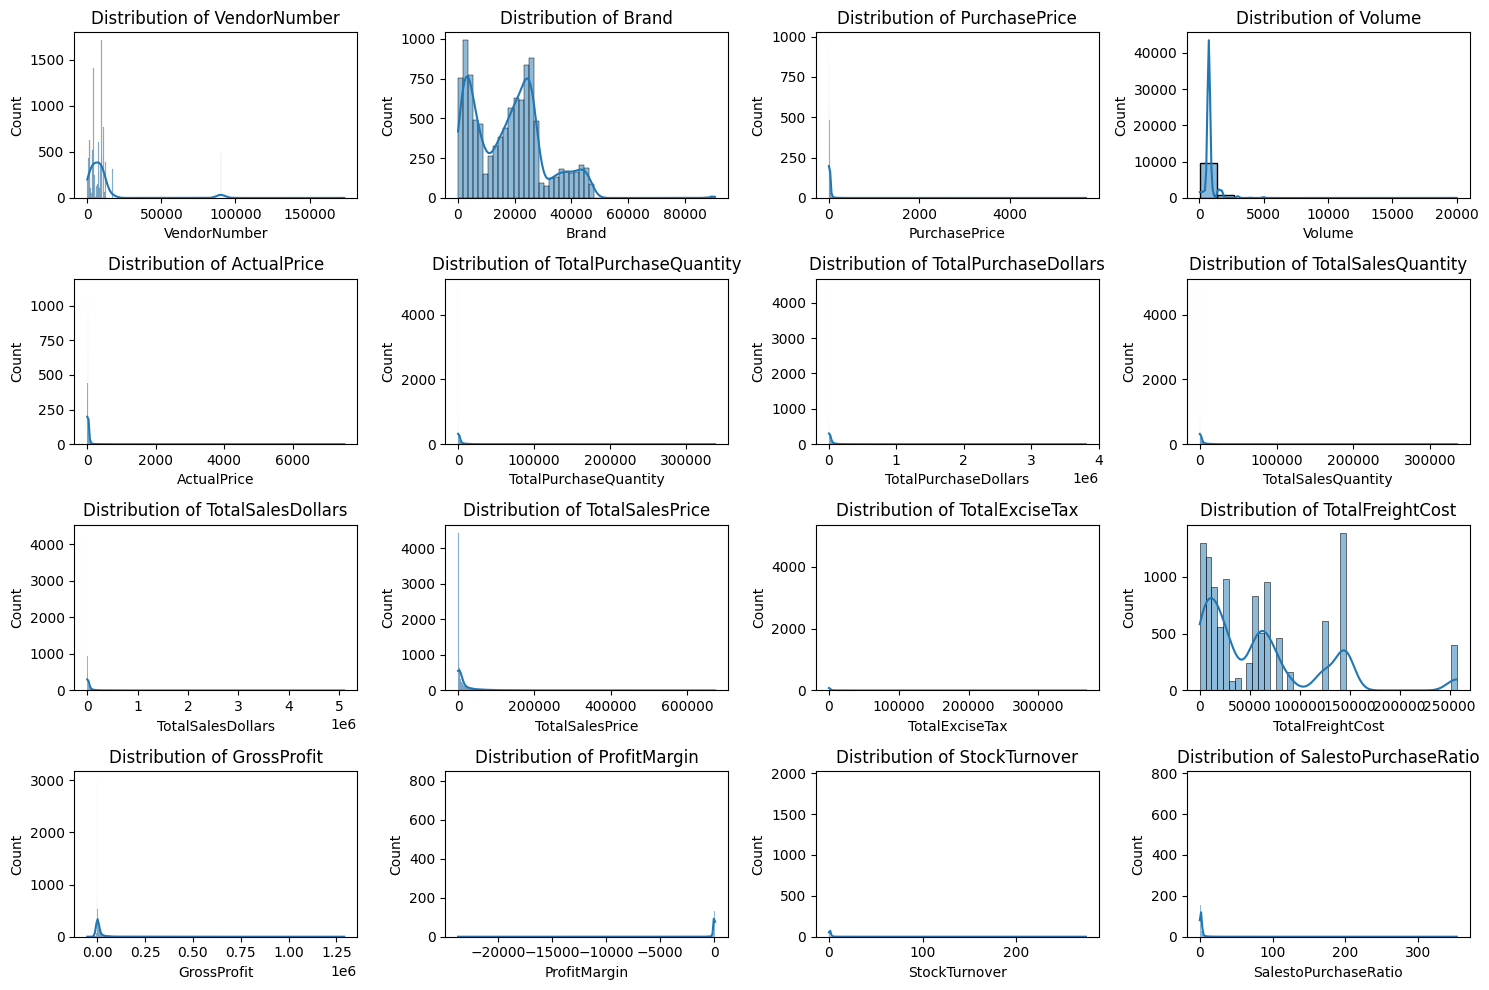

In [65]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

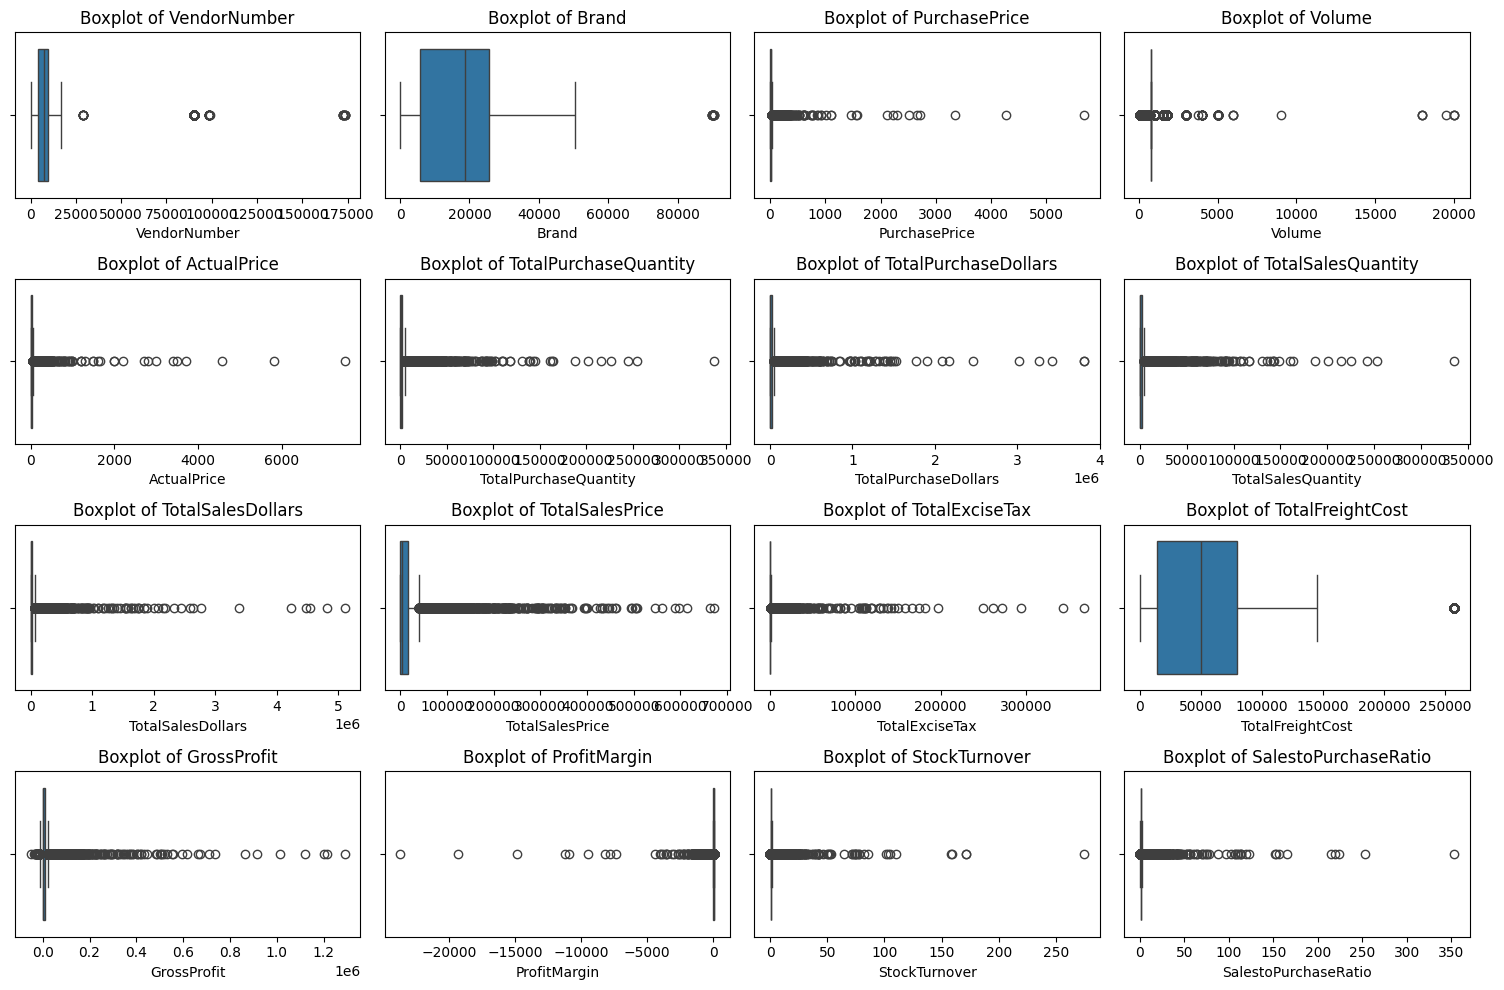

In [66]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Analysis of the Distributions

The histograms show the distribution of important variables from the vendor_sales_summary dataset. Most of the variables are highly right-skewed, indicating that a small number of vendors or brands contribute disproportionately large values compared to the majority.

1. VendorNumber
Most vendor numbers are concentrated within a smaller range.
Presence of a few extremely large vendor IDs/outliers.
Indicates uneven vendor representation in the dataset.
2. Brand
Multiple peaks are visible, suggesting grouped or clustered brand IDs.
Some brands appear much more frequently than others.
Distribution is not uniform, indicating dominance of certain brands.
3. PurchasePrice & ActualPrice
Both variables are heavily right-skewed.
Most products have low prices, while a few products are extremely expensive.
Presence of significant outliers.
Suggests premium products exist but are rare.
4. Volume
Majority of products/vendors operate at low volume.
Very few observations have extremely high sales volume.
Strong positive skewness indicates imbalance in demand or supply.
5. TotalPurchaseQuantity & TotalSalesQuantity
Extremely right-skewed distributions.
Most vendors have relatively small transaction quantities.
A small number of vendors contribute very large quantities.
Indicates concentration of business among top-performing vendors.
6. TotalPurchaseDollars & TotalSalesDollars
Both monetary variables contain extreme high-value outliers.
Majority of vendors operate within lower revenue ranges.
A few vendors dominate total business value.
7. TotalSalesPrice
Similar skewed pattern as sales dollars.
Most transactions occur at lower price ranges.
Some very high-value sales create long distribution tails.
8. TotalExciseTax
Highly concentrated near zero.
Very few records have large excise tax values.
Suggests excise tax applies only to specific products/vendors.
9. TotalFreightCost
Multimodal distribution observed.
Peaks at several ranges may indicate:
Different transportation slabs,
Different vendor regions,
Or shipment categories.
Compared to other features, freight cost is relatively more spread out.
10. GrossProfit
Majority of profits are concentrated near lower values.
Few vendors/products generate extremely high profits.
Strong positive skewness indicates unequal profit distribution.
11. ProfitMargin
Distribution appears heavily negative and compressed near zero.
Presence of extreme negative values suggests:
Possible data quality issues,
Incorrect calculations,
Or vendors operating at heavy losses.
This feature requires further investigation.
12. StockTurnover
Most observations are concentrated near smaller values.
Few very large turnover ratios exist.
Indicates only some vendors/products sell inventory very rapidly.
13. SalesToPurchaseRatio
Most ratios lie close to lower values.
Presence of large outliers suggests unusually high sales relative to purchases for certain vendors.
Could indicate efficient inventory movement or inconsistent purchasing behavior.

In [67]:
#we shouldnot remove all outliers since they may be of premium brands which are expected to have higher sales and revenue. Removing them may lead to loss of valuable insights about the performance of these brands. Instead, we can analyze the outliers separately to understand their impact on the overall data and make informed decisions based on that analysis.
#we must remove the outlier that are inconsistencies like in gross profit etc...
df=pd.read_sql_query("""Select *
FROM vendor_sales_summary
WHERE grossprofit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", con=engine)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8537,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,4.99,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8538,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,0.49,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8539,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,50.0,0.99,2.0,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8540,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,200.0,1.99,1.0,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


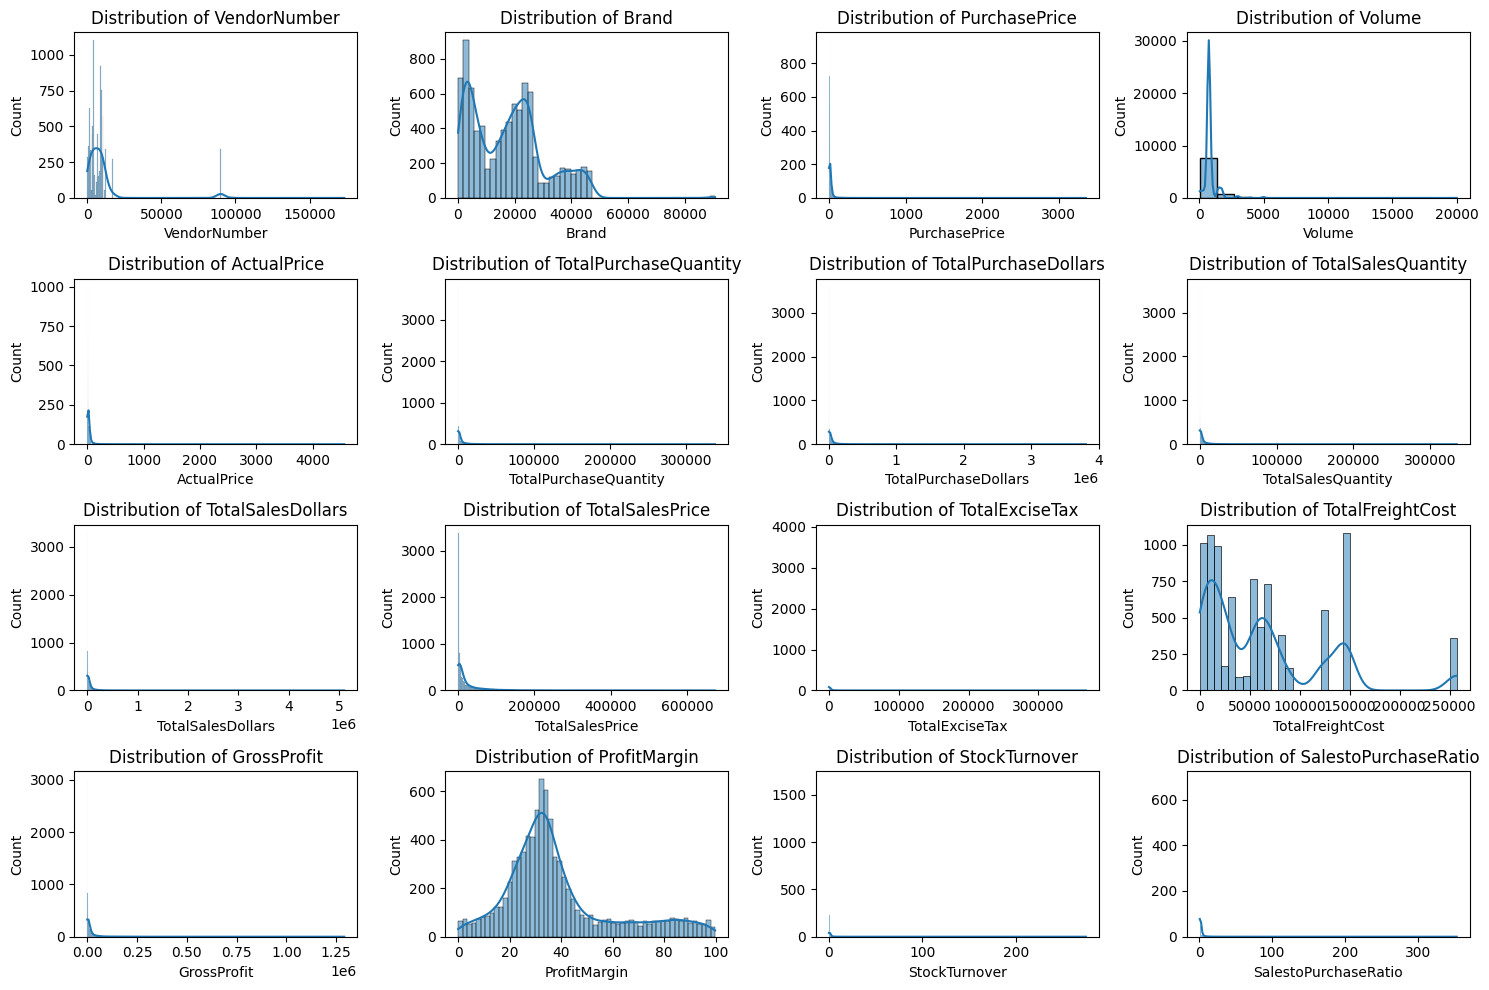

In [68]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

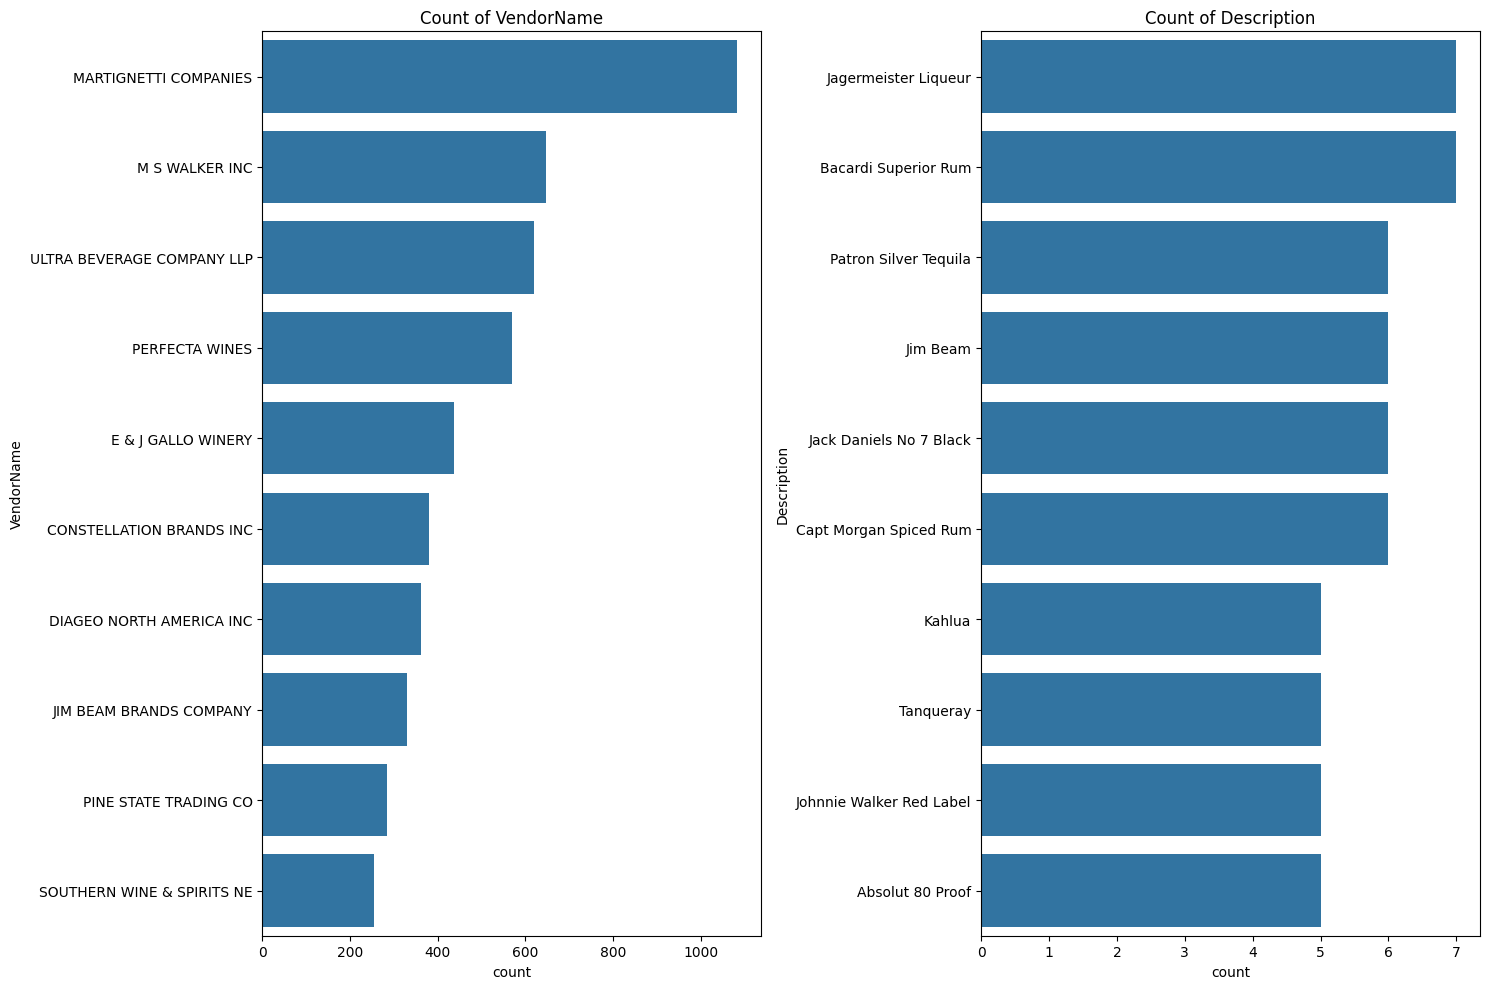

In [69]:
categorical_cols = ['VendorName', 'Description']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2, i+1) #row,col,index
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #top10 categories
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

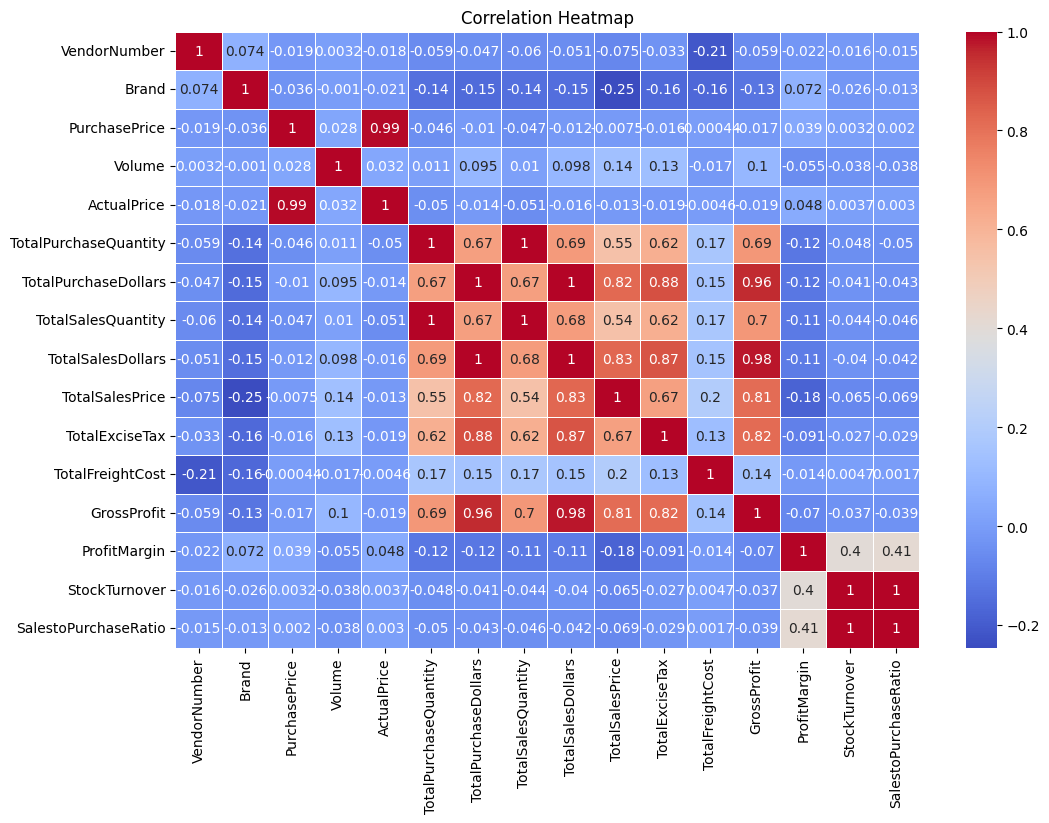

In [70]:
#correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### Correlation Insights
PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

Strong correlation between TotalPurchaseQuantity and TotalSalesQuantity (0.999), confirming efficient inventory turnover.

Negative correlation between ProfitMargin & TotalSalesPrice (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

## Data Analysis

#### Q1.Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins


In [71]:
brand_performance = df.groupby('Description').agg({'TotalSalesDollars':'sum', 'ProfitMargin':'mean'}).reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7700,Zorvino Vyds Sangiovese,10579.03,29.525675
7701,Zuccardi Q Malbec,1639.18,23.981503
7702,Zum Rsl,10857.34,32.675038
7703,Zwack Liqueur,227.88,16.653502


In [72]:
#needs support or promotion
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15) #value at 15% of totalsalesdistribution below which we consider sales to be low   
high_profit_threshold = brand_performance['ProfitMargin'].quantile(0.85) #value at 85% of profitmargin distribution above which we consider profit margin to be high
print(f"Low Sales Threshold: {low_sales_threshold}")
print(f"High Profit Margin Threshold: {high_profit_threshold}")

Low Sales Threshold: 560.146
High Profit Margin Threshold: 64.92990970868915


In [73]:
#filter brands with low sales but high profit margins
target_brands = brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold) & (brand_performance['ProfitMargin'] >= high_profit_threshold)]
print("Brands that may need promotional or pricing adjustments:")
display(target_brands.sort_values(by='TotalSalesDollars'))

Brands that may need promotional or pricing adjustments:


,Description,TotalSalesDollars,ProfitMargin
6197,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6235,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5072,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6243,Sbragia Home Ranch Merlot,549.75,66.444748


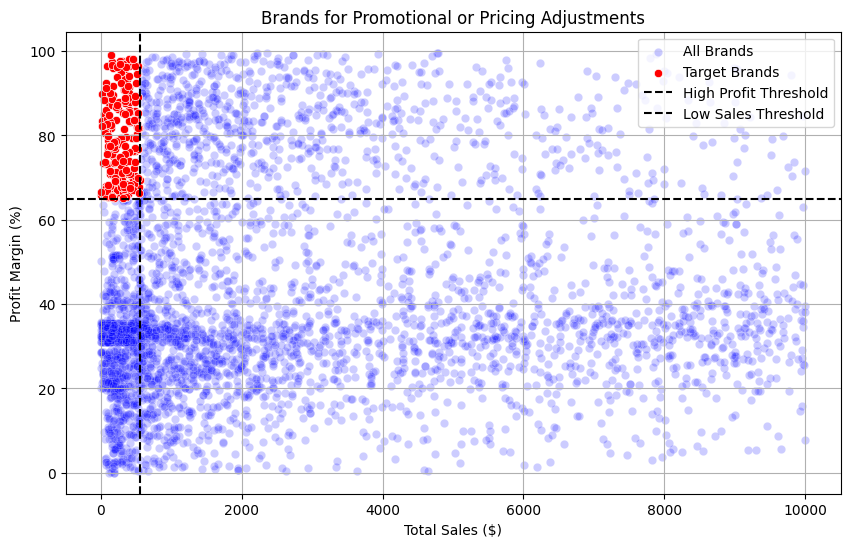

In [74]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance[brand_performance['TotalSalesDollars'] < 10000], #filtering out brands with very high sales to focus on the relevant range
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    high_profit_threshold,
    linestyle='--',
    color='black',
    label='High Profit Threshold'
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")

plt.title("Brands for Promotional or Pricing Adjustments")

plt.legend()
plt.grid(True)

plt.show()

#### Q2.Which vendors and brands demonstrate the highest sales performance?

In [75]:
def format_dollars(value):
    if value>=1_000_000:
        return f"${value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"${value/1_000:.2f}K"
    else:
        return f"${value}"

In [76]:
# from heapq import nlargest


top_vendors=df.groupby('VendorName').agg({'TotalSalesDollars':'sum'}).nlargest(10, 'TotalSalesDollars')
top_brands=df.groupby('Description').agg({'TotalSalesDollars':'sum'}).nlargest(10, 'TotalSalesDollars')
print("Top 10 Vendors by Total Sales:")
display(top_vendors)
print("Top 10 Brands by Total Sales:")
display(top_brands)

Top 10 Vendors by Total Sales:


,TotalSalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,6.799010e+07
MARTIGNETTI COMPANIES,3.933036e+07
PERNOD RICARD USA,3.206320e+07
JIM BEAM BRANDS COMPANY,3.142302e+07
BACARDI USA INC,2.485482e+07
CONSTELLATION BRANDS INC,2.421875e+07
E & J GALLO WINERY,1.839990e+07
BROWN-FORMAN CORP,1.824723e+07
ULTRA BEVERAGE COMPANY LLP,1.645611e+07


Top 10 Brands by Total Sales:


,TotalSalesDollars
Description,
Jack Daniels No 7 Black,7964746.76
Tito's Handmade Vodka,7399657.58
Grey Goose Vodka,7209608.06
Capt Morgan Spiced Rum,6356320.62
Absolut 80 Proof,6244752.03
Jameson Irish Whiskey,5715759.69
Ketel One Vodka,5070083.56
Baileys Irish Cream,4150122.07
Kahlua,3604858.66


In [77]:
top_brands['TotalSalesDollars'] = top_brands['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
print("Top 10 Vendors by Total Sales (Formatted):")
display(top_vendors)
print("Top 10 Brands by Total Sales (Formatted):")
display(top_brands)

Top 10 Vendors by Total Sales (Formatted):


,TotalSalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,$67.99M
MARTIGNETTI COMPANIES,$39.33M
PERNOD RICARD USA,$32.06M
JIM BEAM BRANDS COMPANY,$31.42M
BACARDI USA INC,$24.85M
CONSTELLATION BRANDS INC,$24.22M
E & J GALLO WINERY,$18.40M
BROWN-FORMAN CORP,$18.25M
ULTRA BEVERAGE COMPANY LLP,$16.46M


Top 10 Brands by Total Sales (Formatted):


,TotalSalesDollars
Description,
Jack Daniels No 7 Black,$7.96M
Tito's Handmade Vodka,$7.40M
Grey Goose Vodka,$7.21M
Capt Morgan Spiced Rum,$6.36M
Absolut 80 Proof,$6.24M
Jameson Irish Whiskey,$5.72M
Ketel One Vodka,$5.07M
Baileys Irish Cream,$4.15M
Kahlua,$3.60M


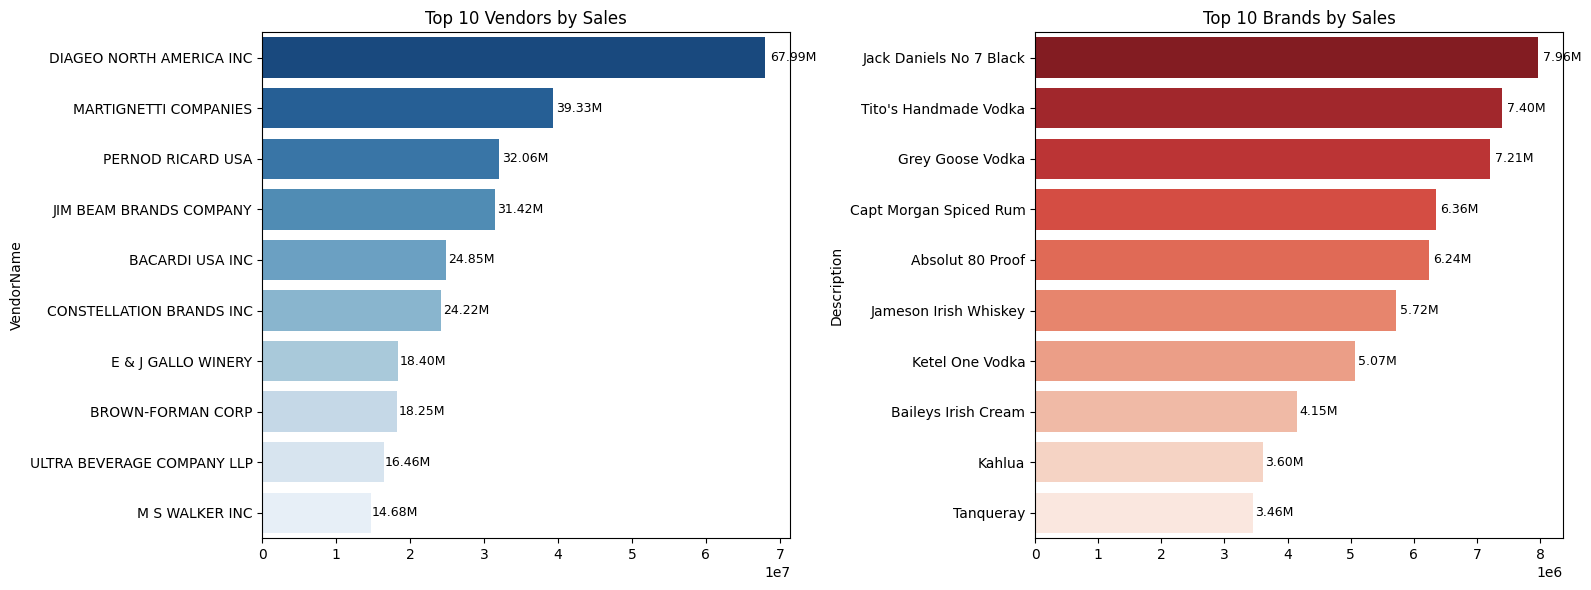

In [78]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return f"{value:.2f}"

# Keep original numeric data
top_vendors = (
    df.groupby('VendorName')['TotalSalesDollars']
      .sum()
      .nlargest(10)
)

top_brands = (
    df.groupby('Description')['TotalSalesDollars']
      .sum()
      .nlargest(10)
)

plt.figure(figsize=(16, 6))

# ---------------- Vendors ----------------
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    x=top_vendors.values,
    y=top_vendors.index,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")
plt.xlabel("")
plt.ylabel("VendorName")

for bar in ax1.patches:
    width = bar.get_width()

    ax1.text(
        width + (width * 0.01),
        bar.get_y() + bar.get_height()/2,
        format_dollars(width),
        va='center',
        fontsize=9
    )

# ---------------- Brands ----------------
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")
plt.xlabel("")
plt.ylabel("Description")

for bar in ax2.patches:
    width = bar.get_width()

    ax2.text(
        width + (width * 0.01),
        bar.get_y() + bar.get_height()/2,
        format_dollars(width),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Q3 Which vendor contribute the most to total sales dollars??

In [79]:
vendor_performance=df.groupby('VendorName').agg({'TotalPurchaseDollars':'sum', 'TotalSalesDollars':'sum','GrossProfit':'sum'}).reset_index()
vendor_performance

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit
0,ADAMBA IMPORTS INTL INC,446.16,704.53,258.37
1,ALISA CARR BEVERAGES,25698.12,104470.94,78772.82
2,ALTAMAR BRANDS LLC,11706.20,15706.81,4000.61
3,AMERICAN SPIRITS EXCHANGE,934.08,1511.16,577.08
4,AMERICAN VINTAGE BEVERAGE,104435.68,139603.53,35167.85
...,...,...,...,...
113,WEIN BAUER INC,42694.64,56217.13,13522.49
114,WESTERN SPIRITS BEVERAGE CO,298416.86,405254.83,106837.97
115,WILLIAM GRANT & SONS INC,5876538.26,7569876.20,1693337.94
116,WINE GROUP INC,5203801.17,8304043.28,3100242.11


In [80]:
vendor_performance['SalesContribution%']=(vendor_performance['TotalSalesDollars']/vendor_performance['TotalSalesDollars'].sum())*100

In [83]:
vendor_performance=round(vendor_performance.sort_values('SalesContribution%',ascending=False), 2)

In [84]:
#top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,SalesContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,67.99M,17.89M,15.44
56,MARTIGNETTI COMPANIES,25.50M,39.33M,13.83M,8.93
67,PERNOD RICARD USA,23.85M,32.06M,8.21M,7.28
45,JIM BEAM BRANDS COMPANY,23.49M,31.42M,7.93M,7.14
6,BACARDI USA INC,17.43M,24.85M,7.42M,5.64
20,CONSTELLATION BRANDS INC,15.27M,24.22M,8.95M,5.50
30,E & J GALLO WINERY,12.07M,18.40M,6.33M,4.18
11,BROWN-FORMAN CORP,13.24M,18.25M,5.01M,4.14
105,ULTRA BEVERAGE COMPANY LLP,11.13M,16.46M,5.33M,3.74
52,M S WALKER INC,9.75M,14.68M,4.93M,3.33


In [86]:
top_vendors['SalesContribution%'].sum() #the top 10 vendors contribute to ~65% of total sales

np.float64(65.32000000000001)

In [ ]:
top_vendors['CumSumContribution%'] = top_vendors['SalesContribution%'].cumsum()
top_vendors
# top_vendors.drop('CumulativeSalesContribution%', axis=1, inplace=True)
# top_vendors

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,SalesContribution%,CumSumContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,67.99M,17.89M,15.44,15.44
56,MARTIGNETTI COMPANIES,25.50M,39.33M,13.83M,8.93,24.37
67,PERNOD RICARD USA,23.85M,32.06M,8.21M,7.28,31.65
45,JIM BEAM BRANDS COMPANY,23.49M,31.42M,7.93M,7.14,38.79
6,BACARDI USA INC,17.43M,24.85M,7.42M,5.64,44.43
20,CONSTELLATION BRANDS INC,15.27M,24.22M,8.95M,5.50,49.93
30,E & J GALLO WINERY,12.07M,18.40M,6.33M,4.18,54.11
11,BROWN-FORMAN CORP,13.24M,18.25M,5.01M,4.14,58.25
105,ULTRA BEVERAGE COMPANY LLP,11.13M,16.46M,5.33M,3.74,61.99
52,M S WALKER INC,9.75M,14.68M,4.93M,3.33,65.32


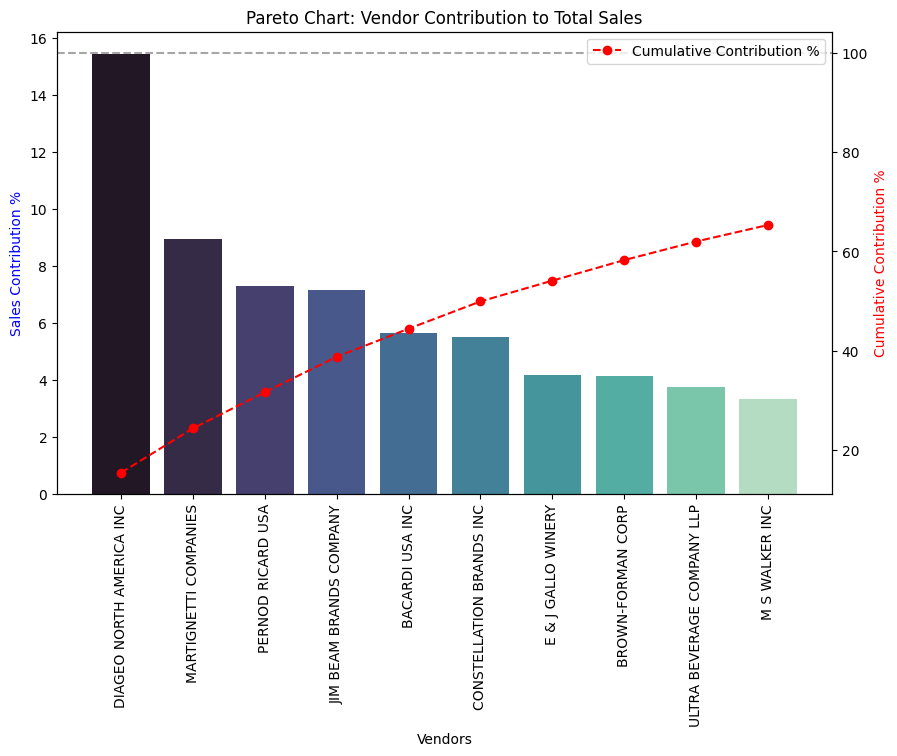

: 

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['SalesContribution%'],
    palette='mako',
    ax=ax1
)

# Add percentage labels on bars
for i, value in enumerate(top_vendors['SalesContribution%']):
    ax1.text(
        i,
        value + 1,
        str(round(value)) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Create second y-axis
ax2 = ax1.twinx()

# Line plot for cumulative contribution%
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['CumSumContribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

# Axis labels and title
ax1.set_xticklabels(
    top_vendors['VendorName'],
    rotation=90
)

ax1.set_ylabel(
    'Sales Contribution %',
    color='blue'
)

ax2.set_ylabel(
    'Cumulative Contribution %',
    color='red'
)

ax1.set_xlabel('Vendors')

ax1.set_title(
    'Pareto Chart: Vendor Contribution to Total Sales'
)

# Reference line at 100%
ax2.axhline(
    y=100,
    color='gray',
    linestyle='dashed',
    alpha=0.7
)

# Legend
ax2.legend(loc='upper right')

plt.show()

#### Q4 How much total procurement is dependent on the top vendors?